# Discount Loyalty Deep Dive: Frequency and Full-Price Conversion

This notebook keeps the two most useful analyses from the four-analysis comparison:

1. **Frequency and inter-purchase interval**: do deeper-discount customers buy less often, or just spend less?
2. **Full-price conversion on repeat orders**: do discount-acquired customers come back and pay full price?

It also adds a follow-up view for customers whose first-order discount was above 10%:

> On their next purchase, how much discount did they use?

**Data boundary:** this notebook uses only `EDA/outputs` and does not read from prepared gold or silver datasets.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
OUTPUT_DIR = PROJECT_ROOT / "EDA" / "outputs"

DATA_SOURCES = {
    "orders": OUTPUT_DIR / "orders.parquet",
    "customers": OUTPUT_DIR / "customers.parquet",
    "discount_depth_bins_reference": OUTPUT_DIR / "05_discount_depth_bins.csv",
}
for name, path in DATA_SOURCES.items():
    assert path.exists(), f"Missing {name}: {path}"
source_text = "\n".join(str(p) for p in DATA_SOURCES.values()).lower()
for forbidden in [("data", "gold"), ("data", "silver")]:
    assert "/".join(forbidden) not in source_text

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

TEAL = "#16B886"
BLUE = "#1F77B4"
ORANGE = "#C76E00"
RED = "#D62728"
NAVY = "#23395B"
SLATE = "#667085"
PURPLE = "#7A5CFA"
GOLD = "#D9A441"

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

def display_table(df, formats=None, columns=None):
    out = df.copy()
    if columns is not None:
        out = out[columns]
    formats = formats or {}
    for col, fmt in formats.items():
        if col in out.columns:
            out[col] = out[col].map(lambda x: "" if pd.isna(x) else fmt.format(x))
    display(out)

print("Sources:")
for name, path in DATA_SOURCES.items():
    print(f"- {name}: {path.relative_to(PROJECT_ROOT)}")

Sources:
- orders: EDA/outputs/orders.parquet
- customers: EDA/outputs/customers.parquet
- discount_depth_bins_reference: EDA/outputs/05_discount_depth_bins.csv


## 1. Build Customer-Level Analysis Table

We rebuild first-order discount depth and downstream behavior from `orders.parquet` and `customers.parquet`.

Two discount-depth measures are retained:

- `discount_depth_codebase`: first discount / first paid order value. This matches the existing chart code.
- `first_gross_discount_rate`: first discount / first gross-before-discount value. This is easier to explain commercially.

The main discount bands follow the existing chart, using the codebase definition so the analysis remains comparable to the original slide.

In [2]:
orders = pd.read_parquet(DATA_SOURCES["orders"]).copy()
customers = pd.read_parquet(DATA_SOURCES["customers"]).copy()
orders["order_date"] = pd.to_datetime(orders["order_date"])
for col in ["Price: Total", "Price: Total Discount", "Price: Total Shipping"]:
    orders[col] = pd.to_numeric(orders[col], errors="coerce").fillna(0)
orders = orders[orders["customer_id"].notna()].copy()
orders["net_revenue_sgd"] = orders["Price: Total"].clip(lower=0)
orders["discount_sgd"] = orders["Price: Total Discount"].clip(lower=0)
orders["gross_before_discount_sgd"] = orders["net_revenue_sgd"] + orders["discount_sgd"]
orders["is_full_price_order"] = orders["discount_sgd"].le(0)

first_order = (
    orders.sort_values("order_date")
    .groupby("customer_id")
    .first()
    .reset_index()[[
        "customer_id", "order_id", "order_date", "channel", "store", "product_category",
        "net_revenue_sgd", "discount_sgd", "gross_before_discount_sgd"
    ]]
    .rename(columns={
        "order_id": "first_order_id",
        "order_date": "first_order_date",
        "channel": "first_channel_from_orders",
        "store": "first_store_from_orders",
        "product_category": "first_product_category_from_orders",
        "net_revenue_sgd": "first_order_value",
        "discount_sgd": "first_disc_amt",
        "gross_before_discount_sgd": "first_gross_value",
    })
)
first_order["cohort_year"] = first_order["first_order_date"].dt.year
first_order["first_discounted"] = first_order["first_disc_amt"].gt(0)
first_order["discount_depth_codebase"] = (
    first_order["first_disc_amt"] / first_order["first_order_value"].replace(0, np.nan)
).fillna(0)
first_order["first_gross_discount_rate"] = np.where(
    first_order["first_gross_value"] > 0,
    first_order["first_disc_amt"] / first_order["first_gross_value"],
    0,
)

BIN_ORDER = ["0% (full price)", "1-5%", "6-10%", "11-20%", "21-30%", "31-50%", "51%+"]
BIN_DISPLAY = ["Full price", "1-5%", "6-10%", "11-20%", "21-30%", "31-50%", "51%+"]
bins = [-0.001, 0, 0.05, 0.10, 0.20, 0.30, 0.50, 1.01]
first_order["discount_bin"] = pd.cut(first_order["discount_depth_codebase"], bins=bins, labels=BIN_ORDER)
first_order["discount_bin_display"] = first_order["discount_bin"].map(dict(zip(BIN_ORDER, BIN_DISPLAY)))
first_order["deep_gt30"] = first_order["discount_depth_codebase"].gt(0.30)

analysis_date = orders["order_date"].max().normalize()
customer_orders = orders.merge(first_order[["customer_id", "first_order_date"]], on="customer_id", how="left")
customer_orders["days_since_first"] = (customer_orders["order_date"] - customer_orders["first_order_date"]).dt.days
customer_orders["is_repeat_order"] = customer_orders["days_since_first"].gt(0)

repeat_orders = customer_orders[customer_orders["is_repeat_order"]].copy()
within_365 = customer_orders[customer_orders["days_since_first"].between(0, 365, inclusive="both")].copy()
repeat_within_365 = repeat_orders[repeat_orders["days_since_first"].le(365)].copy()

post_first = repeat_orders.groupby("customer_id").agg(
    post_first_revenue_sgd=("net_revenue_sgd", "sum"),
    post_first_orders=("order_id", "count"),
    post_first_discounted_order_share=("discount_sgd", lambda s: (s > 0).mean()),
).reset_index()

y1 = within_365.groupby("customer_id").agg(
    y1_revenue_sgd=("net_revenue_sgd", "sum"),
    y1_orders=("order_id", "count"),
    y1_discounted_order_share=("discount_sgd", lambda s: (s > 0).mean()),
).reset_index()

y1_repeat = repeat_within_365.groupby("customer_id").agg(
    y1_repeat_orders=("order_id", "count"),
    y1_repeat_revenue_sgd=("net_revenue_sgd", "sum"),
    y1_full_price_repeat=("is_full_price_order", "any"),
    days_to_second=("days_since_first", "min"),
).reset_index()

full_price_repeat_any = repeat_orders[repeat_orders["is_full_price_order"]].groupby("customer_id").agg(
    any_full_price_repeat=("order_id", "count")
).reset_index()
full_price_repeat_any["any_full_price_repeat"] = True

# Second-order discount metrics: what discount did customers use on their next purchase?
second_order_metrics = (
    repeat_orders.sort_values(["customer_id", "days_since_first", "order_date", "order_id"])
    .groupby("customer_id", as_index=False)
    .first()[["customer_id", "days_since_first", "net_revenue_sgd", "discount_sgd", "gross_before_discount_sgd", "is_full_price_order"]]
    .rename(columns={
        "days_since_first": "second_order_days_since_first",
        "net_revenue_sgd": "second_order_revenue_sgd",
        "discount_sgd": "second_order_discount_sgd",
        "gross_before_discount_sgd": "second_order_gross_sgd",
        "is_full_price_order": "second_order_full_price",
    })
)
second_order_metrics["second_order_discount_rate_gross"] = np.where(
    second_order_metrics["second_order_gross_sgd"] > 0,
    second_order_metrics["second_order_discount_sgd"] / second_order_metrics["second_order_gross_sgd"],
    np.nan,
)
second_order_metrics["second_order_discount_depth_paid"] = np.where(
    second_order_metrics["second_order_revenue_sgd"] > 0,
    second_order_metrics["second_order_discount_sgd"] / second_order_metrics["second_order_revenue_sgd"],
    np.nan,
)

analysis = (
    customers.merge(first_order, on="customer_id", how="left")
    .merge(post_first, on="customer_id", how="left")
    .merge(y1, on="customer_id", how="left")
    .merge(y1_repeat, on="customer_id", how="left")
    .merge(full_price_repeat_any, on="customer_id", how="left")
    .merge(second_order_metrics, on="customer_id", how="left")
)
for col in ["post_first_revenue_sgd", "post_first_orders", "post_first_discounted_order_share", "y1_revenue_sgd", "y1_orders", "y1_discounted_order_share", "y1_repeat_orders", "y1_repeat_revenue_sgd"]:
    analysis[col] = analysis[col].fillna(0)
for col in ["y1_full_price_repeat", "any_full_price_repeat", "second_order_full_price"]:
    analysis[col] = analysis[col].fillna(False).astype(bool)
analysis["repeat_365d"] = analysis["y1_repeat_orders"].gt(0)
analysis["days_to_second_calc"] = analysis.get("days_to_second_y", analysis.get("days_to_second"))
analysis["post_first_revenue_to_first_gross"] = np.where(
    analysis["first_gross_value"] > 0,
    analysis["post_first_revenue_sgd"] / analysis["first_gross_value"],
    np.nan,
)
analysis["lifetime_revenue_to_first_gross"] = np.where(
    analysis["first_gross_value"] > 0,
    analysis["total_revenue"] / analysis["first_gross_value"],
    np.nan,
)
analysis["post_first_revenue_to_first_paid"] = np.where(
    analysis["first_order_value"] > 0,
    analysis["post_first_revenue_sgd"] / analysis["first_order_value"],
    np.nan,
)
analysis["aov_after_first_sgd"] = np.where(
    analysis["post_first_orders"] > 0,
    analysis["post_first_revenue_sgd"] / analysis["post_first_orders"],
    np.nan,
)
analysis["repeat_aov_y1_sgd"] = np.where(
    analysis["y1_repeat_orders"] > 0,
    analysis["y1_repeat_revenue_sgd"] / analysis["y1_repeat_orders"],
    np.nan,
)

main = analysis[analysis["discount_bin"].notna()].copy()
print(f"Customers in analysis table: {len(analysis):,}")
print(f"Customers inside existing discount-depth chart bins: {len(main):,}")
print(f"Customers outside chart bins: {len(analysis) - len(main):,}")
display(main.head())

Customers in analysis table: 13,780
Customers inside existing discount-depth chart bins: 13,306
Customers outside chart bins: 474


,customer_id,first_order_date_x,last_order_date,total_orders,total_revenue,total_discount,ever_subscribed,ever_discounted,first_channel,first_product_cat,first_store,cohort_month,second_order_date,days_to_second_x,is_repeat,lifespan_days,recency_days,first_order_id,first_order_date_y,first_channel_from_orders,first_store_from_orders,first_product_category_from_orders,first_order_value,first_disc_amt,first_gross_value,cohort_year,first_discounted,discount_depth_codebase,first_gross_discount_rate,discount_bin,discount_bin_display,deep_gt30,post_first_revenue_sgd,post_first_orders,post_first_discounted_order_share,y1_revenue_sgd,y1_orders,y1_discounted_order_share,y1_repeat_orders,y1_repeat_revenue_sgd,y1_full_price_repeat,days_to_second_y,any_full_price_repeat,second_order_days_since_first,second_order_revenue_sgd,second_order_discount_sgd,second_order_gross_sgd,second_order_full_price,second_order_discount_rate_gross,second_order_discount_depth_paid,repeat_365d,days_to_second_calc,post_first_revenue_to_first_gross,lifetime_revenue_to_first_gross,post_first_revenue_to_first_paid,aov_after_first_sgd,repeat_aov_y1_sgd
0,6327387259135,2022-06-29 00:00:00+08:00,2022-06-29 00:00:00+08:00,1,"1,693.120",0.000,False,False,Subscription,Unknown,SG,2022-06,NaT,NaN,False,0,1401,4992506265855,2022-06-29 00:00:00+08:00,Subscription,SG,Unknown,"1,693.120",0.000,"1,693.120",2022,False,0.000,0.000,0% (full price),Full price,False,0.000,0.000,0.000,"1,693.120",1,0.000,0.000,0.000,False,NaN,False,NaN,NaN,NaN,NaN,False,NaN,NaN,False,NaN,0.000,1.000,0.000,NaN,NaN
1,6327388733695,2021-10-04 00:00:00+08:00,2024-05-03 00:00:00+08:00,2,336.010,5.990,False,True,Subscription,Unknown,SG,2021-10,2024-05-03 00:00:00+08:00,942.000,True,942,727,4992632127743,2021-10-04 00:00:00+08:00,Subscription,SG,Unknown,222.200,0.000,222.200,2021,False,0.000,0.000,0% (full price),Full price,False,113.810,1.000,1.000,222.200,1,0.000,0.000,0.000,False,NaN,False,942.000,113.810,5.990,119.800,False,0.050,0.053,False,NaN,0.512,1.512,0.512,113.810,NaN
2,6327388799231,2021-02-05 00:00:00+08:00,2021-11-05 00:00:00+08:00,3,93.070,0.000,False,False,Subscription,Unknown,SG,2021-02,2021-10-11 00:00:00+08:00,248.000,True,273,1637,4992730300671,2021-02-05 00:00:00+08:00,Subscription,SG,Unknown,19.000,0.000,19.000,2021,False,0.000,0.000,0% (full price),Full price,False,74.070,2.000,0.000,93.070,3,0.000,2.000,74.070,True,248.000,True,248.000,21.750,0.000,21.750,True,0.000,0.000,True,248.000,3.898,4.898,3.898,37.035,37.035
3,6327389520127,2021-03-04 00:00:00+08:00,2021-03-04 00:00:00+08:00,1,29.000,0.000,False,False,Subscription,Unknown,SG,2021-03,NaT,NaN,False,0,1883,4992722010367,2021-03-04 00:00:00+08:00,Subscription,SG,Unknown,29.000,0.000,29.000,2021,False,0.000,0.000,0% (full price),Full price,False,0.000,0.000,0.000,29.000,1,0.000,0.000,0.000,False,NaN,False,NaN,NaN,NaN,NaN,False,NaN,NaN,False,NaN,0.000,1.000,0.000,NaN,NaN
4,6327390699775,2020-08-18 00:00:00+08:00,2020-11-29 00:00:00+08:00,2,492.980,0.000,False,False,Subscription,Unknown,SG,2020-08,2020-11-29 00:00:00+08:00,103.000,True,103,1978,4992793739519,2020-08-18 00:00:00+08:00,Subscription,SG,Unknown,139.900,0.000,139.900,2020,False,0.000,0.000,0% (full price),Full price,False,353.080,1.000,0.000,492.980,2,0.000,1.000,353.080,True,103.000,True,103.000,353.080,0.000,353.080,True,0.000,0.000,True,103.000,2.524,3.524,2.524,353.080,353.080


## 2. Frequency And Inter-Purchase Interval

This separates whether deep-discount customers look weaker because they:

- buy less often, or
- buy the same number of times but spend less per order.

Frequency is often the better customer-loyalty signal; AOV is more pricing and basket-mix dependent.

In [3]:
frequency_analysis = main.groupby("discount_bin", observed=True).agg(
    customers=("customer_id", "count"),
    avg_total_orders=("total_orders", "mean"),
    avg_post_first_orders=("post_first_orders", "mean"),
    avg_y1_orders=("y1_orders", "mean"),
    avg_y1_repeat_orders=("y1_repeat_orders", "mean"),
    median_days_to_second=("days_to_second_calc", "median"),
    avg_aov_after_first_sgd=("aov_after_first_sgd", "mean"),
    avg_repeat_aov_y1_sgd=("repeat_aov_y1_sgd", "mean"),
).reindex(BIN_ORDER).reset_index()
frequency_analysis["discount_bin_display"] = BIN_DISPLAY

display_table(
    frequency_analysis,
    {
        "customers": "{:,.0f}", "avg_total_orders": "{:.2f}", "avg_post_first_orders": "{:.2f}",
        "avg_y1_orders": "{:.2f}", "avg_y1_repeat_orders": "{:.2f}", "median_days_to_second": "{:.0f}",
        "avg_aov_after_first_sgd": "S${:,.0f}", "avg_repeat_aov_y1_sgd": "S${:,.0f}",
    },
    columns=["discount_bin_display", "customers", "avg_post_first_orders", "avg_y1_repeat_orders", "median_days_to_second", "avg_aov_after_first_sgd", "avg_repeat_aov_y1_sgd"],
)

full_freq = frequency_analysis.loc[0, "avg_post_first_orders"]
last_freq = frequency_analysis.loc[len(frequency_analysis)-1, "avg_post_first_orders"]
display(Markdown(
    f"**Read:** post-first order frequency moves from {full_freq:.2f} orders for full-price starts to {last_freq:.2f} orders for 51%+ starts. "
    "This shows whether the issue is loyalty frequency, not just discounted basket size."
))

,discount_bin_display,customers,avg_post_first_orders,avg_y1_repeat_orders,median_days_to_second,avg_aov_after_first_sgd,avg_repeat_aov_y1_sgd
0,Full price,"9,398",1.13,0.68,57,S$141,S$145
1,1-5%,186,0.47,0.37,43,S$75,S$75
2,6-10%,395,0.61,0.43,50,S$82,S$85
3,11-20%,"1,250",0.49,0.43,42,S$83,S$83
4,21-30%,458,0.65,0.50,56,S$92,S$93
5,31-50%,"1,189",0.48,0.41,46,S$110,S$112
6,51%+,430,0.43,0.32,53,S$57,S$54


**Read:** post-first order frequency moves from 1.13 orders for full-price starts to 0.43 orders for 51%+ starts. This shows whether the issue is loyalty frequency, not just discounted basket size.

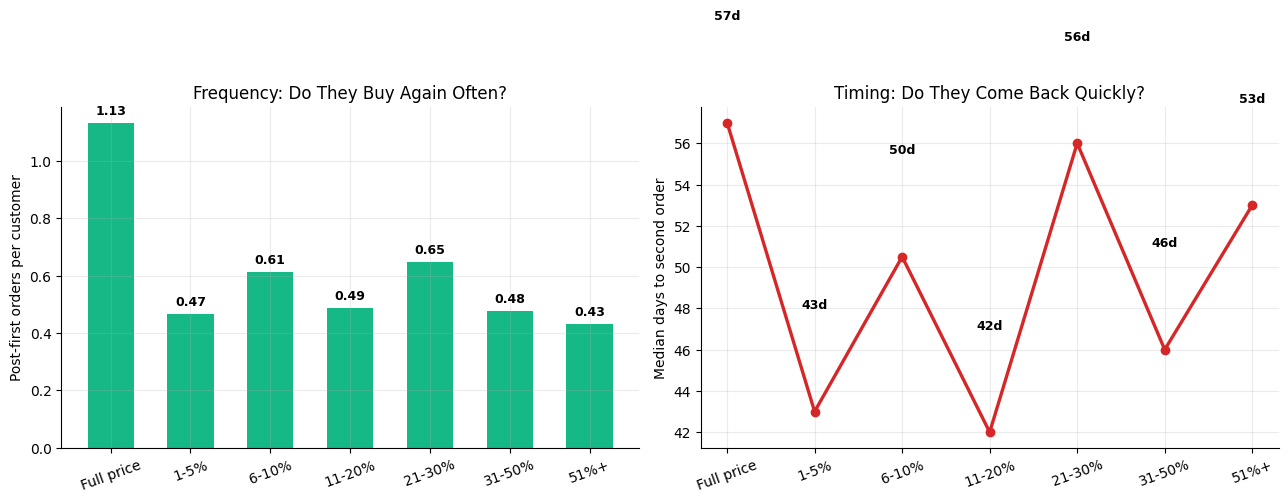

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
x = np.arange(len(frequency_analysis))
axes[0].bar(x, frequency_analysis["avg_post_first_orders"], color=TEAL, width=0.58)
axes[0].set_xticks(x)
axes[0].set_xticklabels(frequency_analysis["discount_bin_display"], rotation=20)
axes[0].set_ylabel("Post-first orders per customer")
axes[0].set_title("Frequency: Do They Buy Again Often?")
for xi, v in enumerate(frequency_analysis["avg_post_first_orders"]):
    axes[0].text(xi, v + 0.03, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

axes[1].plot(x, frequency_analysis["median_days_to_second"], color=RED, marker="o", linewidth=2.4)
axes[1].set_xticks(x)
axes[1].set_xticklabels(frequency_analysis["discount_bin_display"], rotation=20)
axes[1].set_ylabel("Median days to second order")
axes[1].set_title("Timing: Do They Come Back Quickly?")
for xi, v in enumerate(frequency_analysis["median_days_to_second"]):
    if not pd.isna(v):
        axes[1].text(xi, v + 5, f"{v:.0f}d", ha="center", fontsize=9, fontweight="bold")
fig.tight_layout()
plt.show()

## 3. Full-Price Conversion On Repeat Orders

This is the sharpest commercial loyalty test.

Question: **Do discount-acquired customers ever come back and pay full price?**

This directly addresses whether the customer becomes less promotion-dependent after acquisition.

In [5]:
full_price_analysis = main.groupby("discount_bin", observed=True).agg(
    customers=("customer_id", "count"),
    repeat_rate_365d=("repeat_365d", "mean"),
    full_price_repeat_365d=("y1_full_price_repeat", "mean"),
    any_full_price_repeat=("any_full_price_repeat", "mean"),
    y1_discounted_order_share=("y1_discounted_order_share", "mean"),
    post_first_discounted_order_share=("post_first_discounted_order_share", "mean"),
).reindex(BIN_ORDER).reset_index()
full_price_analysis["discount_bin_display"] = BIN_DISPLAY
full_price_analysis["repeat_to_full_price_gap_pp"] = (full_price_analysis["repeat_rate_365d"] - full_price_analysis["full_price_repeat_365d"]) * 100

display_table(
    full_price_analysis,
    {
        "customers": "{:,.0f}", "repeat_rate_365d": "{:.1%}", "full_price_repeat_365d": "{:.1%}",
        "any_full_price_repeat": "{:.1%}", "y1_discounted_order_share": "{:.1%}",
        "post_first_discounted_order_share": "{:.1%}", "repeat_to_full_price_gap_pp": "{:+.1f} pp",
    },
    columns=["discount_bin_display", "customers", "repeat_rate_365d", "full_price_repeat_365d", "any_full_price_repeat", "post_first_discounted_order_share", "repeat_to_full_price_gap_pp"],
)

full_fp = full_price_analysis.loc[0, "full_price_repeat_365d"]
last_fp = full_price_analysis.loc[len(full_price_analysis)-1, "full_price_repeat_365d"]
display(Markdown(
    f"**Read:** full-price repeat within 365 days moves from {full_fp:.1%} for full-price starts to {last_fp:.1%} for 51%+ starts. "
    "This is the cleanest commercial loyalty metric because it shows whether customers return without needing another discount."
))

,discount_bin_display,customers,repeat_rate_365d,full_price_repeat_365d,any_full_price_repeat,post_first_discounted_order_share,repeat_to_full_price_gap_pp
0,Full price,"9,398",27.7%,24.6%,27.7%,7.8%,+3.1 pp
1,1-5%,186,17.2%,10.8%,11.8%,7.1%,+6.5 pp
2,6-10%,395,23.8%,10.4%,12.4%,16.7%,+13.4 pp
3,11-20%,"1,250",22.8%,9.0%,9.8%,16.1%,+13.8 pp
4,21-30%,458,24.0%,6.8%,8.1%,19.5%,+17.2 pp
5,31-50%,"1,189",21.2%,5.0%,5.6%,18.3%,+16.2 pp
6,51%+,430,18.6%,4.9%,6.3%,15.7%,+13.7 pp


**Read:** full-price repeat within 365 days moves from 24.6% for full-price starts to 4.9% for 51%+ starts. This is the cleanest commercial loyalty metric because it shows whether customers return without needing another discount.

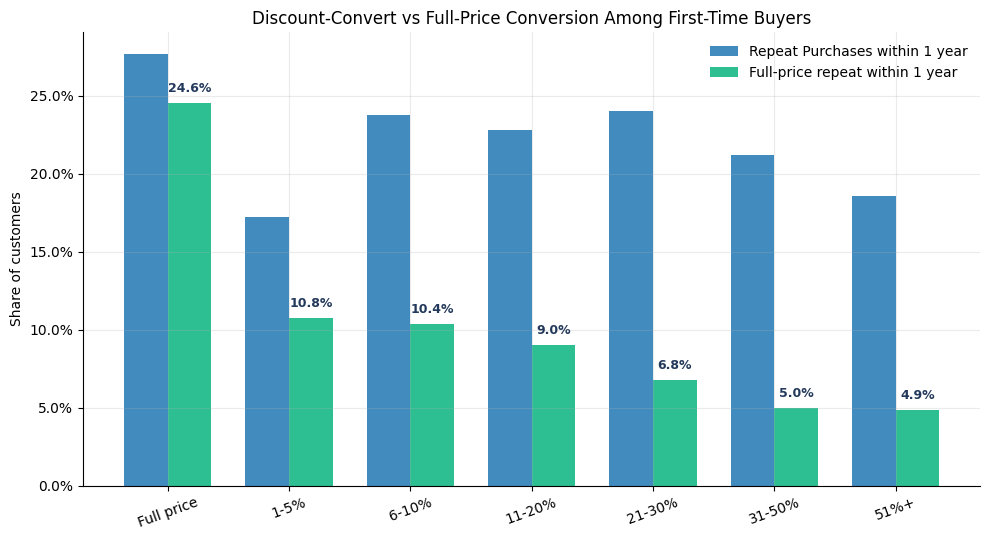

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(full_price_analysis))
w = 0.36
ax.bar(x - w/2, full_price_analysis["repeat_rate_365d"] * 100, width=w, color=BLUE, alpha=0.85, label="Repeat Purchases within 1 year")
ax.bar(x + w/2, full_price_analysis["full_price_repeat_365d"] * 100, width=w, color=TEAL, alpha=0.9, label="Full-price repeat within 1 year")
ax.set_xticks(x)
ax.set_xticklabels(full_price_analysis["discount_bin_display"], rotation=20)
ax.set_ylabel("Share of customers")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Discount-Convert vs Full-Price Conversion Among First-Time Buyers")
ax.legend(frameon=False)
for xi, v in enumerate(full_price_analysis["full_price_repeat_365d"] * 100):
    ax.text(xi + w/2, v + 0.7, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold", color=NAVY)
fig.tight_layout()
plt.show()

## 4. Follow-Up: For >10% First-Order Discounts, What Happens On The Next Purchase?

The full-price conversion chart tells us whether discount-acquired customers come back at full price. This section goes one level deeper:

> Among customers whose first order had more than 10% discount depth, how much discount did they use on their second order?

This is useful because a repeat order is not always true loyalty. If customers repeat only with another discount, the brand may be training discount dependency rather than building full-price habit.

The left-hand chart includes customers who did not make a second purchase, so it uses the full >10% first-discount cohort as the denominator. The right-hand box plot is repeaters-only and shows the distribution of net paid second-order value by the discount used on that second order.

In [7]:
def second_discount_band(rate):
    if pd.isna(rate):
        return "No second order"
    if rate <= 0:
        return "0% / full price"
    if rate <= 0.10:
        return "1-10%"
    if rate <= 0.20:
        return "11-20%"
    if rate <= 0.30:
        return "21-30%"
    return "31%+"

SECOND_BAND_ORDER = ["No second order", "0% / full price", "1-10%", "11-20%", "21-30%", "31%+"]
SECOND_REPEAT_BAND_ORDER = ["0% / full price", "1-10%", "11-20%", "21-30%", "31%+"]
first_gt10 = analysis[analysis["discount_depth_codebase"].gt(0.10)].copy()
first_gt10["second_discount_band"] = pd.Categorical(
    first_gt10["second_order_discount_rate_gross"].apply(second_discount_band),
    categories=SECOND_BAND_ORDER,
    ordered=True,
)
first_gt10_repeaters = first_gt10[first_gt10["second_order_discount_rate_gross"].notna()].copy()

second_summary_all = (
    first_gt10.groupby("second_discount_band", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_second_order_discount_rate=("second_order_discount_rate_gross", "mean"),
        avg_second_order_revenue_sgd=("second_order_revenue_sgd", "mean"),
        avg_first_discount_depth=("discount_depth_codebase", "mean"),
        avg_days_to_second=("second_order_days_since_first", "mean"),
    )
    .reindex(SECOND_BAND_ORDER)
    .reset_index()
)
second_summary_all["share_of_all_first_gt10"] = second_summary_all["customers"] / len(first_gt10)

second_summary_repeaters = second_summary_all[second_summary_all["second_discount_band"].astype(str).ne("No second order")].copy()
second_summary_repeaters["share_of_second_orders"] = second_summary_repeaters["customers"] / second_summary_repeaters["customers"].sum()

first_gt10_overall = pd.DataFrame([{
    "customers_first_gt10": len(first_gt10),
    "made_second_order": first_gt10["second_order_discount_rate_gross"].notna().sum(),
    "second_order_rate": first_gt10["second_order_discount_rate_gross"].notna().mean(),
    "second_order_full_price_rate_among_all": first_gt10["second_order_discount_rate_gross"].fillna(np.nan).eq(0).mean(),
    "second_order_full_price_rate_among_repeaters": first_gt10_repeaters["second_order_discount_rate_gross"].eq(0).mean(),
    "avg_second_order_discount_rate_among_repeaters": first_gt10_repeaters["second_order_discount_rate_gross"].mean(),
}])

display_table(
    first_gt10_overall,
    {
        "customers_first_gt10": "{:,.0f}", "made_second_order": "{:,.0f}", "second_order_rate": "{:.1%}",
        "second_order_full_price_rate_among_all": "{:.1%}", "second_order_full_price_rate_among_repeaters": "{:.1%}",
        "avg_second_order_discount_rate_among_repeaters": "{:.1%}",
    },
)

display_table(
    second_summary_all,
    {
        "customers": "{:,.0f}", "share_of_all_first_gt10": "{:.1%}",
        "avg_second_order_discount_rate": "{:.1%}", "avg_second_order_revenue_sgd": "S${:,.0f}",
        "avg_first_discount_depth": "{:.1%}", "avg_days_to_second": "{:.0f}",
    },
)

display(Markdown(
    f"**Read:** among customers whose first order was discounted by more than 10%, "
    f"{first_gt10_overall.loc[0, 'second_order_rate']:.1%} made a second order and "
    f"{1 - first_gt10_overall.loc[0, 'second_order_rate']:.1%} did not. "
    f"Only {first_gt10_overall.loc[0, 'second_order_full_price_rate_among_all']:.1%} of all >10% first-discount customers came back at full price on the second order."
))

,customers_first_gt10,made_second_order,second_order_rate,second_order_full_price_rate_among_all,second_order_full_price_rate_among_repeaters,avg_second_order_discount_rate_among_repeaters
0,"3,801",849,22.3%,4.4%,19.7%,28.9%


,second_discount_band,customers,avg_second_order_discount_rate,avg_second_order_revenue_sgd,avg_first_discount_depth,avg_days_to_second,share_of_all_first_gt10
0,No second order,"2,952",,S$0,58.7%,147,77.7%
1,0% / full price,167,0.0%,S$72,28.8%,133,4.4%
2,1-10%,73,7.2%,S$102,30.4%,118,1.9%
3,11-20%,151,15.1%,S$86,28.9%,109,4.0%
4,21-30%,197,26.0%,S$139,35.7%,64,5.2%
5,31%+,261,63.8%,S$47,82.3%,81,6.9%


**Read:** among customers whose first order was discounted by more than 10%, 22.3% made a second order and 77.7% did not. Only 4.4% of all >10% first-discount customers came back at full price on the second order.

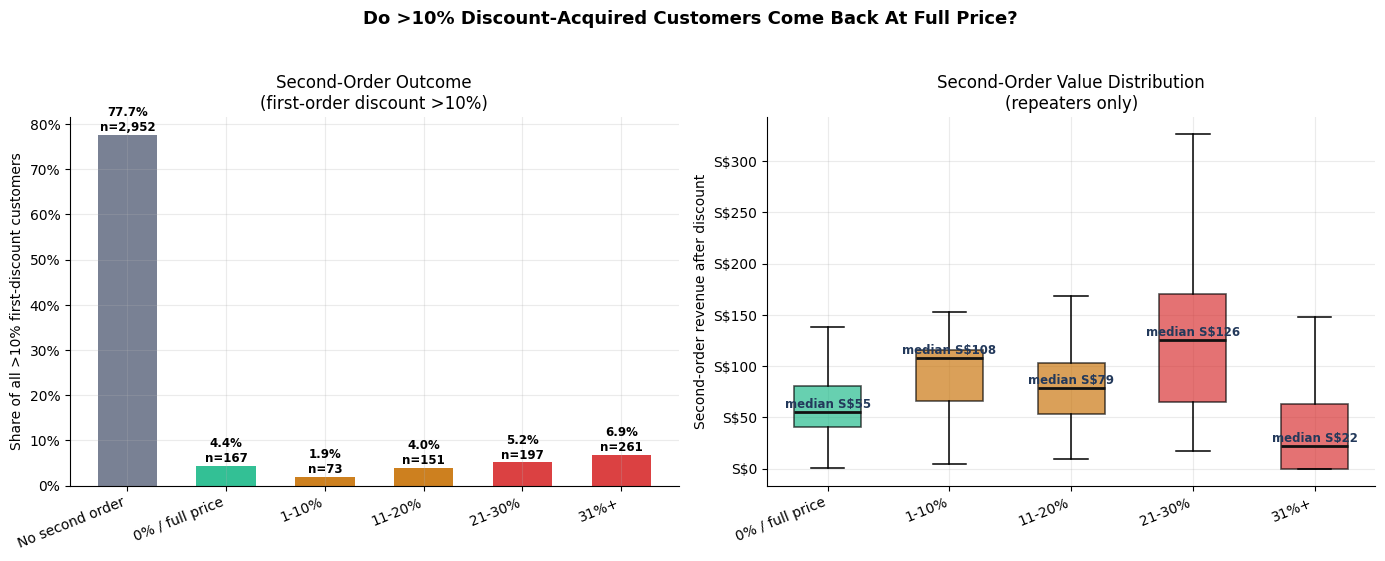

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
plot_all = second_summary_all.dropna(subset=["customers"]).copy()
x = np.arange(len(plot_all))
colors = [SLATE if b == "No second order" else TEAL if b == "0% / full price" else ORANGE if b in ["1-10%", "11-20%"] else RED for b in plot_all["second_discount_band"].astype(str)]

axes[0].bar(x, plot_all["share_of_all_first_gt10"] * 100, color=colors, alpha=0.88, width=0.60)
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_all["second_discount_band"], rotation=22, ha="right")
axes[0].set_ylabel("Share of all >10% first-discount customers")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_title("Second-Order Outcome\n(first-order discount >10%)")
for xi, row in enumerate(plot_all.itertuples()):
    axes[0].text(xi, row.share_of_all_first_gt10 * 100 + 0.8, f"{row.share_of_all_first_gt10:.1%}\nn={row.customers:,.0f}", ha="center", fontsize=8.5, fontweight="bold")

plot_repeat = second_summary_repeaters.dropna(subset=["customers"]).copy()
box_data = [
    first_gt10_repeaters.loc[first_gt10_repeaters["second_discount_band"].astype(str).eq(str(b)), "second_order_revenue_sgd"].dropna()
    for b in plot_repeat["second_discount_band"]
]
box_colors = [TEAL if b == "0% / full price" else ORANGE if b in ["1-10%", "11-20%"] else RED for b in plot_repeat["second_discount_band"].astype(str)]
box = axes[1].boxplot(
    box_data,
    patch_artist=True,
    widths=0.55,
    showfliers=False,
    medianprops=dict(color="#111111", linewidth=2),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.1),
    capprops=dict(linewidth=1.1),
)
for patch, color in zip(box["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
axes[1].set_xticks(np.arange(1, len(plot_repeat) + 1))
axes[1].set_xticklabels(plot_repeat["second_discount_band"], rotation=22, ha="right")
axes[1].set_ylabel("Second-order revenue after discount")
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("S${x:,.0f}"))
axes[1].set_title("Second-Order Value Distribution\n(repeaters only)")

medians = [d.median() if len(d) else np.nan for d in box_data]
for xi, (median, row) in enumerate(zip(medians, plot_repeat.itertuples()), start=1):
    if not pd.isna(median):
        axes[1].text(xi, median + 4, f"median S${median:,.0f}", ha="center", fontsize=8.5, fontweight="bold", color=NAVY)

fig.suptitle("Do >10% Discount-Acquired Customers Come Back At Full Price?", y=1.03, fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 5. Recommended Slide Story

### Keep These Two Charts

1. **Frequency and inter-purchase interval**
   - Use this to show whether discount-acquired customers buy less often, not just whether they spend less.
   - This helps separate loyalty behavior from basket-size and price effects.

2. **Full-price conversion on repeat orders**
   - Use this as the main commercial loyalty chart.
   - It answers the sharper question: “Do customers acquired with discounts come back without needing another discount?”

### Add This Follow-Up Chart

For customers whose first-order discount was above 10%, show the discount used on their second order.

This is the bridge from “repeat” to “true loyalty”:

> A repeat purchase is only high-quality if the customer is willing to come back at full price or with much less discounting.

### Suggested Slide Title

**Deep discounts weaken the path to full-price repeat**

### Suggested Talking Point

“The issue is not only whether discount-acquired customers come back. The more important question is whether they come back without another discount. The full-price conversion view and the second-order discount view show whether discounting is creating loyal buyers or discount-dependent repeaters.”

In [9]:
for name, path in DATA_SOURCES.items():
    lowered = str(path).lower()
    for forbidden in [("data", "gold"), ("data", "silver")]:
        assert "/".join(forbidden) not in lowered, path
print("Source-path guardrail passed: no forbidden prepared data paths configured.")

Source-path guardrail passed: no forbidden prepared data paths configured.
